In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import sys
sys.path.append("../datasets/libs/image-utils/src")
from my_io import load_gray_image, print_image
from spatial_transforms import get_bounding_box
from filters import anscombe_transform
from quality_metrics import compute_epi_torch, compute_cnr_torch, psnr_with_mask



#Enter device here, 'cuda' for GPU, and 'cpu' for CPU
device = 'cuda'

In [43]:
n = 1
im_data = f'../datasets/dataset/im_{n}'
gt = torch.load(f'{im_data}/gt.pt', weights_only=True)[None,...].to(device)
noisy = torch.load(f'{im_data}/Std0.10.pt', weights_only=True)[None,...]
noisy=anscombe_transform(noisy, 0.10).to(device)

mask =  load_gray_image(
        f"../datasets/dataset/im_{n}/mask.png",
        as_mask=True,
    )

In [44]:
class Net(nn.Module):
    def __init__(self,n_chan,chan_embed=48):
        super(Net, self).__init__()

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)
        self.conv1 = nn.Conv2d(n_chan,chan_embed,3,padding=1)
        self.conv2 = nn.Conv2d(chan_embed, chan_embed, 3, padding = 1)
        self.conv3 = nn.Conv2d(chan_embed, n_chan, 1)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.conv3(x)

        return x

n_chan = gt.shape[1]
model = Net(n_chan).to(device)
print("The number of parameters of the network is: ",  sum(p.numel() for p in model.parameters() if p.requires_grad))

The number of parameters of the network is:  21313


In [45]:
def pair_downsampler(img):
    #img has shape B C H W
    c = img.shape[1]

    filter1 = torch.FloatTensor([[[[0 ,0.5],[0.5, 0]]]]).to(img.device)
    filter1 = filter1.repeat(c,1, 1, 1)

    filter2 = torch.FloatTensor([[[[0.5 ,0],[0, 0.5]]]]).to(img.device)
    filter2 = filter2.repeat(c,1, 1, 1)

    output1 = F.conv2d(img, filter1, stride=2, groups=c)
    output2 = F.conv2d(img, filter2, stride=2, groups=c)

    return output1, output2

Text(0.5, 1.0, 'Second downsampled')

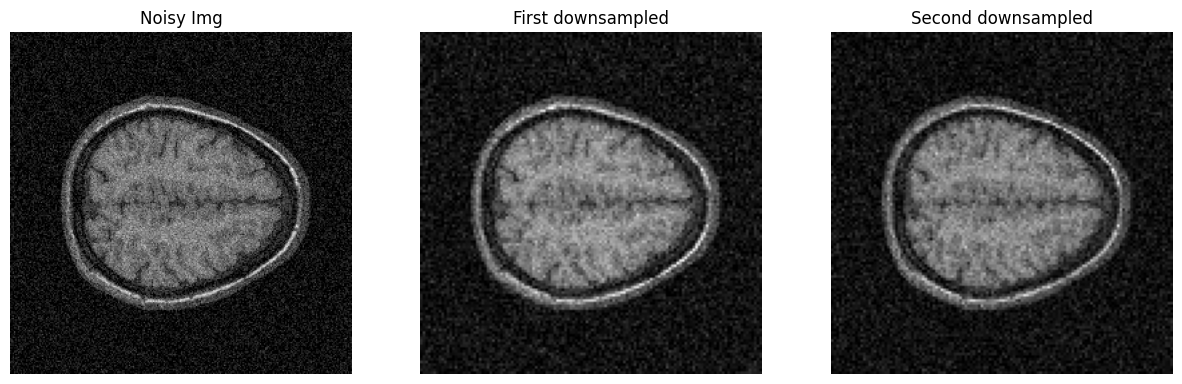

In [46]:
img1, img2 = pair_downsampler(noisy)

img0 = noisy.cpu().squeeze(0).permute(1,2,0)
img1 = img1.cpu().squeeze(0).permute(1,2,0)
img2 = img2.cpu().squeeze(0).permute(1,2,0)

fig, ax = plt.subplots(1, 3,figsize=(15, 15))

ax[0].imshow(img0, cmap='gray')
ax[0].set_axis_off()
ax[0].set_title('Noisy Img')

ax[1].imshow(img1, cmap='gray')
ax[1].set_axis_off()
ax[1].set_title('First downsampled')

ax[2].imshow(img2, cmap='gray')
ax[2].set_axis_off()
ax[2].set_title('Second downsampled')

In [47]:
def mse(gt: torch.Tensor, pred:torch.Tensor)-> torch.Tensor:
    loss = torch.nn.MSELoss()
    return loss(gt,pred)

def loss_func(noisy_img):
    noisy1, noisy2 = pair_downsampler(noisy_img)

    pred1 =  noisy1 - model(noisy1)
    pred2 =  noisy2 - model(noisy2)

    loss_res = 1/2*(mse(noisy1,pred2)+mse(noisy2,pred1))

    noisy_denoised =  noisy_img - model(noisy_img)
    denoised1, denoised2 = pair_downsampler(noisy_denoised)

    loss_cons=1/2*(mse(pred1,denoised1) + mse(pred2,denoised2))

    loss = loss_res + loss_cons

    return loss

In [ ]:
def train(model, optimizer, noisy_img):

    loss = loss_func(noisy_img)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# def test(model, noisy_img, clean_img):

#     with torch.no_grad():
#         pred = torch.clamp(noisy_img - model(noisy_img),0,1)
#         MSE = mse(clean_img, pred).item()
#         PSNR = 10*np.log10(1/MSE)

#     return PSNR

def denoise(model, noisy_img):

    with torch.no_grad():
        pred = torch.clamp( noisy_img - model(noisy_img),0,1)

    return pred

In [49]:
max_epoch = 3000     # training epochs
lr = 0.001           # learning rate
step_size = 1000     # number of epochs at which learning rate decays
gamma = 0.5          # factor by which learning rate decays

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

In [50]:
for epoch in range(max_epoch):
    train(model, optimizer, noisy)
    scheduler.step()

In [51]:
denoised_img = denoise(model, noisy)

In [ ]:
denoised = denoised_img.cpu().squeeze(0)
clean = gt.cpu().squeeze(0)
noisy = noisy.cpu().squeeze(0)#.permute(2,0,1)

[Text(0.5, 0, '25.97 dB')]

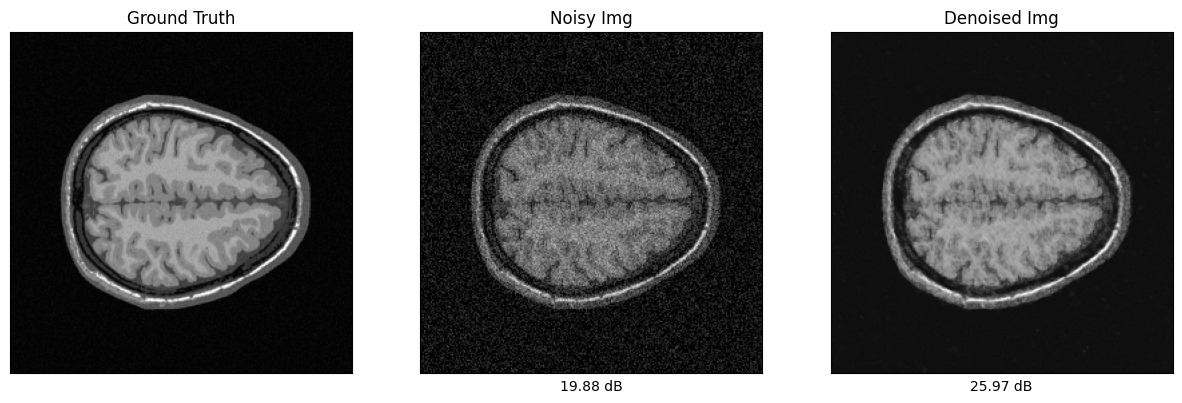

In [59]:
fig, ax = plt.subplots(1, 3,figsize=(15, 15))



ax[0].imshow(clean.squeeze(), cmap='gray')
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Ground Truth')

ax[1].imshow(noisy.squeeze(), cmap='gray')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Noisy Img')
noisy_psnr =  psnr_with_mask(clean,noisy,mask).item()
ax[1].set(xlabel= str(round(noisy_psnr,2)) + ' dB')

ax[2].imshow(denoised.squeeze(), cmap='gray')
ax[2].set_xticks([])
ax[2].set_yticks([])
result_psnr = psnr_with_mask(clean, denoised, mask).item()
ax[2].set_title('Denoised Img')
ax[2].set(xlabel= str(round(result_psnr,2)) + ' dB')